<h1> Project 1- Aspect-based Sentiment Analysis with Pre-trained Sentiment Lexicon</h1>
<p> Aspect-based Sentiment Analysis is the analysis that attempts to find out the sentiment associated with different aspects of a similar topic. For example, a restaurant manager may want to know how its customers feel about their dining experiences. A restaurant has many aspects that concerns a dining experience, such as price, food, and service. If the sentiment that is associated with these aspects can be identified, the analysis result can be more helpful for the restaurant manager than just presenting an overall sentiment. In this project about aspect-based sentiment analysis, the focus was on different aspects that concern the quality of a K-Pop group. These aspects are the song, the vocal of the performer, the dance, the music video, and the Korean proficiency. </p>
<p> There are many ways for machine to detect sentiments from text. In this project, I used a rule-based pre-trained lexicon sentiment model, VADER, to perform such a task. With some preliminary test, I found it works the best at sentence-level. It also handles negation quite well. Therefore, I decided to focus on the aspect at the sentence-level as well to gain the most precise result. </p>
<p> The detailed process of analysis is explained as follows. </p>

In [1]:
import pandas as pd
import numpy as np
import random

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

<h2> Retrieve the Data for analysis </h2>

In [2]:
data = pd.read_pickle('data_with_class.pickle')
data.head()

,comment,author,group,processed_comment,quality,national-ethnic,kpop,language
0,imagine asking for exo tickets for your birthd...,Annaliese Bain,exp edition,imagine asking exo ticket birthday mom get ins...,0,0,0,en
1,i wanna know what kpop idols think about this,johnhyuck,exp edition,want know kpop idol think,0,0,0,en
2,They're not terrible at singing or anything bu...,Katherine Wells,exp edition,terrible singing anything think need kpop much...,1,0,0,en
3,those weird crying pictures are terrifying wtf,Emily T,exp edition,weird cry picture terrifying wtf,0,0,0,en
4,"so i'm waiting for btx, eighteen, monsta z, go...",maya,exp edition,waiting btx eighteen monsta got debut,0,0,0,en


<h2> Customize Vader Sentiment Dictionary to Make the Analysis Meet the K-Pop Context More </h2>

<p> For example, the original VADER dictionary considers fighting as a negative expression, but in K-Pop, it is often used as a synonym to cheer-up, which is a positive expression. </p>

In [3]:
custom_sentiment = {
                    'fighting': 2.0,
                    'koreaboo': -2.0,
                    'cringe': -2.0,
                    }

analyzer = SentimentIntensityAnalyzer()
analyzer.lexicon.update(custom_sentiment)

<h2> Define a Function that Returns the Sentiment Analysis Result of VADER  </h2>

In [4]:
def vader_sentiment_type(sentence):

    sentiment_dict = analyzer.polarity_scores(sentence)

    score = sentiment_dict['compound']
    
    if score > 0:
        pred_sentiment = 'pos'
    elif score == 0:
        pred_sentiment = 'neu'
    else:
        pred_sentiment = 'neg'
        
    return pred_sentiment

<h2> Extract Aspect at the Sentence Level. </h2>

<p> In this project, I used whether a concept word (dance, voice, etc.) occurs in a sentence as the rule to determine whether the given sentence is of which aspect or not. </p>

In [5]:
song = list()
voice = list()
dance = list()
mv = list()
korean = list()

for i, r in data.iterrows():
    
    who = r['group']
    
    doc = sent_tokenize(r['comment'])
    for sent in doc:
        sent = sent.lower()
        
        if 'song' in sent:
            
            ps = vader_sentiment_type(sent)
            song.append((ps, who))
            
        if 'voice' in sent or 'vocal' in sent:
            
            ps = vader_sentiment_type(sent)
            voice.append((ps, who))
    
        if 'dance' in sent:
            
            ps = vader_sentiment_type(sent)
            dance.append((ps, who))
            
        if 'mv' in sent:
            
            ps = vader_sentiment_type(sent)
            mv.append((ps, who))
            
        if 'korean' in sent:
            
            ps = vader_sentiment_type(sent)
            korean.append((ps, who))

<h2> Analysis: Sentiment Distribution of Each Aspect </h2>

<p> The analysis attempts to visualize the sentiment distribution of different aspects concerning the quality of a K-Pop group, using the comments collected from nine K-Pop groups' YouTube Music Video. </p>

In [6]:
def sentiment_percentage_calculator(a_list):
    
    size = len(a_list)
    
    smal_list = [s for (s, g) in a_list]
    
    neg = smal_list.count('neg')
    neu = smal_list.count('neu')
    pos = smal_list.count('pos')

    return neg/size, neu/size, pos/size

In [7]:
s = sentiment_percentage_calculator(song)
v = sentiment_percentage_calculator(voice)
d = sentiment_percentage_calculator(dance)
m = sentiment_percentage_calculator(mv)
k = sentiment_percentage_calculator(korean)

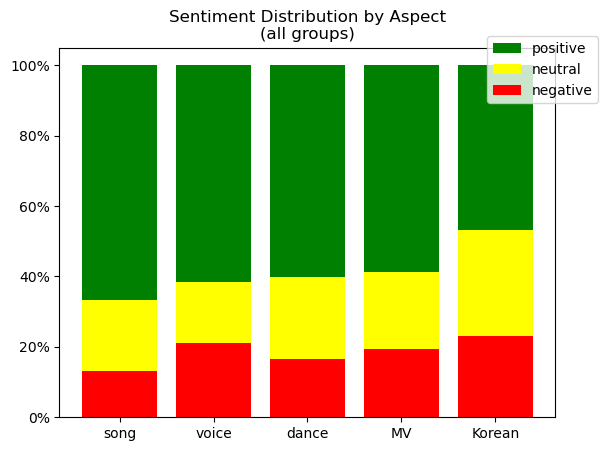

In [8]:
neg_perc = list()
neu_perc = list()
pos_perc = list()

for neg, neu, pos in [s, v, d, m, k]:
    
    neg_perc.append(neg*100)
    neu_perc.append(neu*100)
    pos_perc.append(pos*100)
    
pos_bottom = [a+b for a, b in zip(neg_perc, neu_perc)]

labels = ['song', 'voice', 'dance', 'MV', 'Korean']

fig, ax = plt.subplots()

ax.bar(labels, pos_perc, bottom=pos_bottom, label='positive', color='green')
ax.bar(labels, neu_perc, bottom=neg_perc, label='neutral', color='yellow')
ax.bar(labels, neg_perc, label='negative', color='red')

ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.set_title('Sentiment Distribution by Aspect\n(all groups)')
ax.legend(loc=1, bbox_to_anchor=(1.1, 1.05))

plt.show()

<h2> Interpretation </h2>

<p> 1. The result shows that the positive sentiment occupies the most proportion in all aspects than negative sentiment, which meets the assumption that fans are more likely to watch a music video and comment than others. </p>
<p> 2. It can be observed that the proportion of positive sentiment in the aspect of Korean was less than in other aspects, which suggested some underlying complaints in this aspect. </p>
<p> 3. However, the word Korean can both mean the language and the performer's ethnicity. How the negative sentiment was actually associated with the word requires further analysis, which is the limitation of lexicon-based sentiment analysis. </p>
<p> 4. To overcome this limitation, I performed the following analysis. </p>

<h2> Analysis: Group Distribution of Negative Sentiment by Aspect </h2>

<p> This analysis focused on the negative sentiment, examining which group comprised the most share of negative sentiment concerning each aspect. </p>

In [9]:
def sentiment_distribution(a_list, sentiment_type):
    
    neg_list = list()
    neu_list = list()
    pos_list = list()
    
    for s, g in a_list:
        if s == 'neg':
            neg_list.append(g)
        if s == 'neu':
            neu_list.append(g)
        if s == 'pos':
            pos_list.append(g)
            
    neg = pd.Series(neg_list).value_counts(normalize=True).sort_index()
    neu = pd.Series(neu_list).value_counts(normalize=True).sort_index()
    pos = pd.Series(pos_list).value_counts(normalize=True).sort_index()
    
    if sentiment_type == 'neg':
        return neg
    elif sentiment_type == 'neu':
        return neu
    elif sentiment_type == 'pos':
        return pos
    else:
        return neg, neu, pos

In [10]:
s = sentiment_distribution(song, 'neg')
v = sentiment_distribution(voice, 'neg')
d = sentiment_distribution(dance, 'neg')
m = sentiment_distribution(mv, 'neg')
k = sentiment_distribution(korean, 'neg')

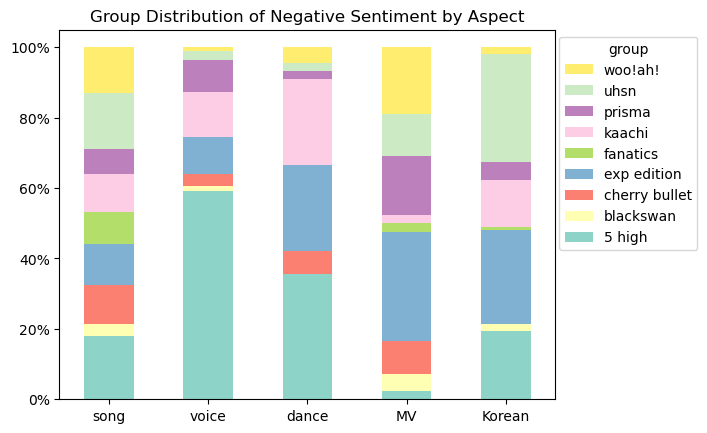

In [11]:
group = s.index

song = s*100
voice = v*100
dance = d*100
mv = m*100
korean = k*100

df = pd.DataFrame(index=['song', 'voice', 'dance', 'MV', 'Korean'], columns=group)
df.loc['song'] = song
df.loc['voice'] = voice
df.loc['dance'] = dance
df.loc['MV'] = mv
df.loc['Korean'] = korean

df = df.fillna(0)
df = df.reset_index()

ax = df.plot(x='index', kind='bar', stacked=True, cmap='Set3')

ax.set_title('Group Distribution of Negative Sentiment by Aspect')

ax.set_xlabel('')
ax.set_xticklabels(['song', 'voice', 'dance', 'MV', 'Korean'], rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='group', loc=1, bbox_to_anchor=(1.3, 1.00))

plt.show()

<h2> Interpretation </h2>

<p> 1. Concerning the song, the negative sentiment distribution was quite equal between groups. </p>
<p> 2. Concerning the voice and the dance, the most negative sentiment was targeted toward 5 High. </p>
<p> 3. Concerning the Korean, aspect where there was a greater proportion of negative sentiment, it was UHSN, EXP Edition, and 5 High that contributed to most of the negative sentiment. With the result, a researcher can further analyze negative comments about Korean and about UHSN, EXP Edition, and 5 High qualitatively, to discern whether the negative sentiment was about the language or the ethnicity. </p>